<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
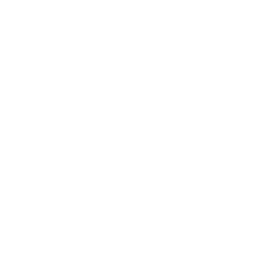
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">분기별 등록을 월별로 보간하기</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 제약 / 임상 운영 &nbsp;|&nbsp; 2026년 3월</p>
</div>
</div>
</div>

## 요약

이 실습 예제는 PROC EXPAND로 **분기별** 임상시험 등록 건수를 **월별** 추정치로 변환하여, 사이트 단위 자원 계획이 월별 주기로 운영될 수 있게 합니다. 합성 시험은 두 지역(북미와 유럽)의 **네 개 연구자 사이트**를 **여덟 분기**(2024년 1분기부터 2025년 4분기)에 걸쳐 다루며, **32개 분기별 관측치**를 제공합니다. PROC EXPAND는 각 사이트의 시계열을 분기별에서 월별 빈도로 보간하여 그 32개 분기별 행을 **96개 월별 행**으로 바꿉니다. 등록 건수는 `METHOD=JOIN`(구간별 선형, 모든 추정치를 음수가 아니게 유지)으로 보간하고, 누적 합계는 `METHOD=SPLINE`으로 보간합니다. 보간된 월별 시계열은 원래의 분기별 기준점을 정확히 통과하므로, 변환은 이미 보고된 분기별 수치를 바꾸지 않고 분기 내 세부를 더합니다.

## 데이터 소스

| 소스 | 설명 | 레코드 수 |
|--------|-------------|---------|
| WORK.ENROLLMENT_QTR | 사이트별 분기 등록 건수(4개 사이트 x 8개 분기) | 32 |
| WORK.SITE_MASTER | 사이트 참조: 이름, 국가, 지역, PI | 4 |

---

In [1]:
/* --------------------------------------------------------
   사이트별 분기 등록 건수를 생성합니다.
   4개 사이트 x 8개 분기 (2024년 1분기 ~ 2025년 4분기) = 32행.
   완만한 계절 변동과 약간의 잡음을 더한 상승 곡선(초기 저조,
   이후 안정)으로 현실적인 등록 형태를 만듭니다.
   -------------------------------------------------------- */
데이터 work.enrollment_qtr;
    호출 streaminit(42);
    형식 quarter_date yyq7.;
    배열 capacity[4] _temporary_ (12 9 14 8);
    반복 site_num = 1 까지 4;
        site_id = cat('SITE-', PUT(site_num, z3.));
        region  = ifc(site_num <= 2, '북미', '유럽');
        base_rate = capacity[site_num];
        반복 qtr_seq = 0 까지 7;
            quarter_date = intnx('qtr', '01JAN2024'd, qtr_seq);
            ramp_factor  = 0.3 + 0.7 * (1 - EXP(-0.4 * qtr_seq));
            seasonal_adj = 1 + 0.15 * sin(2 * 3.14159 * qtr_seq / 4);
            noise = round(rand('normal', 0, 1.5), 1);
            enrolled_count = MAX(0,
                round(base_rate * ramp_factor * seasonal_adj + noise, 1));
            출력;
        종료;
    종료;
    제거 site_num base_rate ramp_factor seasonal_adj noise qtr_seq;
실행;

/* 각 사이트 내 누적 등록 건수 계산 */
처리 정렬 데이터=work.enrollment_qtr;
    기준 site_id quarter_date;
실행;

데이터 work.enrollment_qtr;
    설정 work.enrollment_qtr;
    기준 site_id;
    보존 cum_enrolled 0;
    만약 first.site_id 이면 cum_enrolled = 0;
    cum_enrolled + enrolled_count;
    cumulative_enrolled = cum_enrolled;
    제거 cum_enrolled;
실행;



NOTE: DATA work.enrollment_qtr


NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.enrollment_qtr


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   사이트 마스터 참조 테이블 (4개 사이트, 2개 지역)
   -------------------------------------------------------- */
데이터 work.site_master;
    길이 site_id $8 site_name $40 region $20 country $20 pi_name $30;
    배열 names[4] $40 _temporary_ (
        'Metro General Hospital'   'University Medical Center'
        'London Royal Infirmary'   'Berlin Charite Campus'
    );
    배열 countries[4] $20 _temporary_ ('미국' '미국' '영국' '독일');
    반복 i = 1 까지 4;
        site_id   = cat('SITE-', PUT(i, z3.));
        site_name = names[i];
        country   = countries[i];
        region    = ifc(i <= 2, '북미', '유럽');
        pi_name   = cat('Dr. Investigator-', PUT(i, z2.));
        출력;
    종료;
    제거 i;
실행;



NOTE: DATA work.site_master


NOTE: Wrote work.site_master (4 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   지역별 분기 등록 건수 기준선 요약
   -------------------------------------------------------- */
처리 평균 데이터=work.enrollment_qtr n sum mean MAX;
    분류 region;
    변수 enrolled_count cumulative_enrolled;
    라벨 region = "지역"
          enrolled_count = "등록 건수"
          cumulative_enrolled = "누적 등록 건수";
    출력 out=work.qtr_baseline
        sum(enrolled_count)=total_enrolled
        mean(enrolled_count)=avg_per_quarter
        MAX(cumulative_enrolled)=max_cumulative;
실행;

처리 인쇄 데이터=work.qtr_baseline noobs 라벨;
    라벨 region = "지역"
          total_enrolled = "총 등록 건수"
          avg_per_quarter = "분기당 평균 등록 건수"
          max_cumulative = "최대 누적 등록 건수";
    제목 "분기별 지역 등록 건수 기준선";
실행;


                                                  The MEANS Procedure

                                    Analysis Variable : enrolled_count 등록 건수

        지역                N Obs            Sum           Mean        Maximum
        --------------------------------------------------------------------
        북미                   16    115.0000000      7.1875000     10.0000000
        유럽                   16    120.0000000      7.5000000     13.0000000
        --------------------------------------------------------------------

                              Analysis Variable : cumulative_enrolled 누적 등록 건수

        지역                N Obs            Sum           Mean        Maximum
        --------------------------------------------------------------------
        북미                   16    474.0000000     29.6250000     63.0000000
        유럽                   16    493.0000000     30.8125000     81.0000000
        --------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: Output dataset work.qtr_baseline has 3 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.qtr_baseline

NOTE: PROC PRINT completed: 3 observations printed, 6 variables


기준선은 균형 설계를 확인합니다: 각 지역이 **16개 분기별 관측치**를 제공합니다. 북미는 총 **115명**을 등록하고(사이트-분기당 평균 **7.19**), 유럽은 **120명**(평균 **7.50**)을 등록합니다. 여덟 분기에 걸쳐 도달한 가장 큰 누적 건수는 북미의 **63**에 대비되는 **81명**(유럽 SITE-003)입니다.

---

                                                    분기별 지역 등록 건수 기준선                                                    




NOTE: DATA work.traj


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.traj (32 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.traj

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


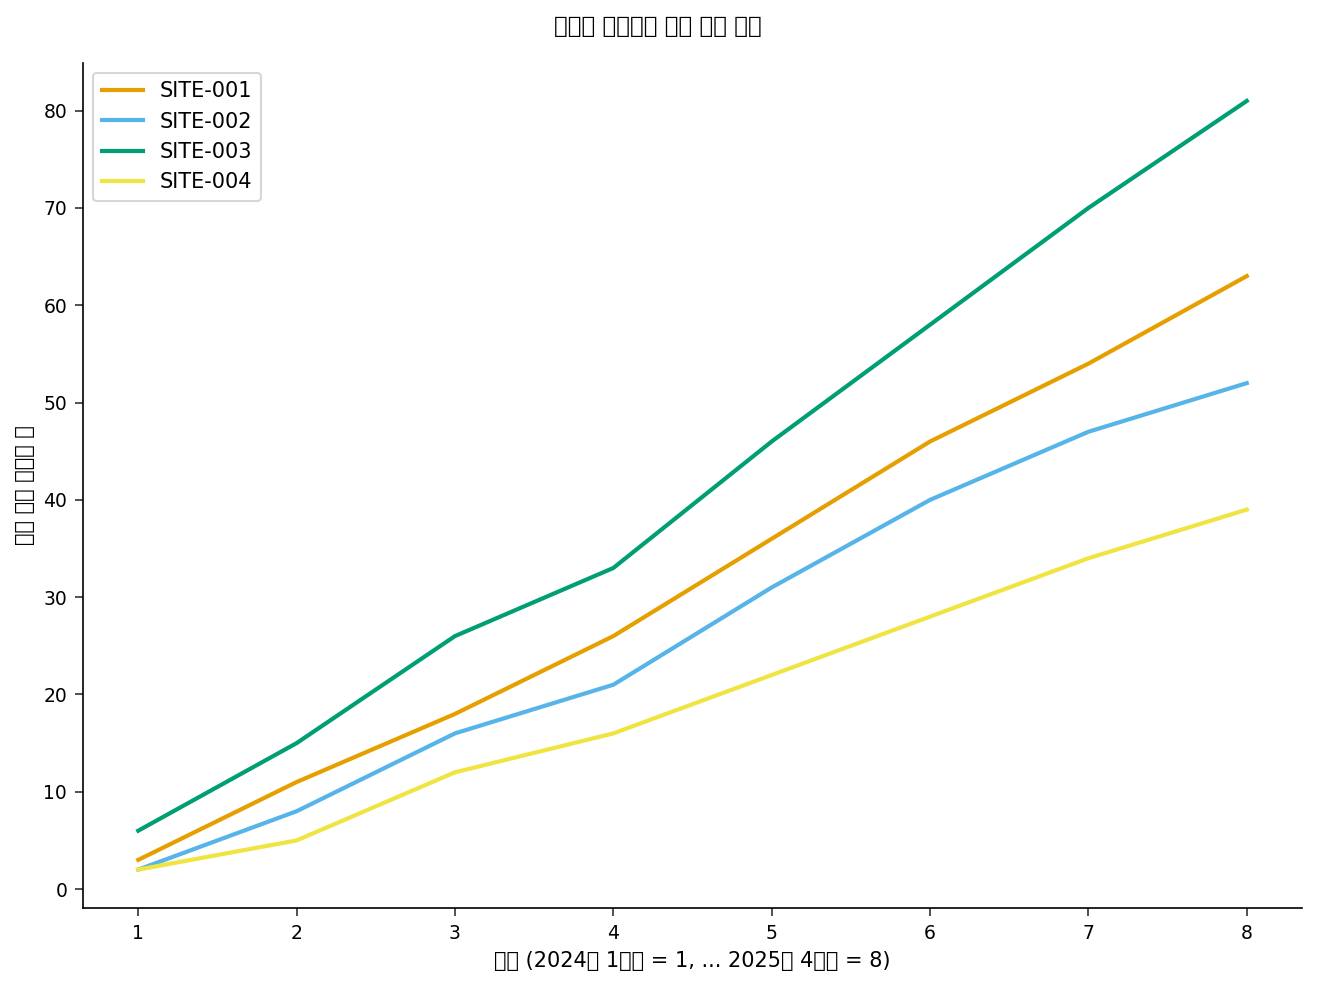

In [4]:
/* --------------------------------------------------------
   사이트별 분기 누적 등록 추이.
   깔끔한 축을 위해 분기 인덱스(1..8)에 대해 그립니다.
   -------------------------------------------------------- */
데이터 work.traj;
    설정 work.enrollment_qtr;
    기준 site_id;
    보존 quarter_index 0;
    만약 first.site_id 이면 quarter_index = 0;
    quarter_index + 1;
실행;

처리 SGPLOT 데이터=work.traj;
    SERIES x=quarter_index y=cumulative_enrolled
        / GROUP=site_id LINEATTRS=(thickness=2) MARKERS;
    XAXIS 라벨="분기 (2024년 1분기 = 1, ... 2025년 4분기 = 8)"
        integer VALUES=(1 까지 8 기준 1);
    YAXIS 라벨="누적 등록 피험자 수";
    제목 "연구자 사이트별 누적 등록 추이";
실행;


---

In [5]:
/* --------------------------------------------------------
   PROC EXPAND는 ID 변수가 각 BY 그룹 내에서 정렬되어 있어야
   하므로, 변환 전에 사이트 및 분기 기준으로 정렬합니다.
   -------------------------------------------------------- */
처리 정렬 데이터=work.enrollment_qtr;
    기준 site_id quarter_date;
실행;



NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   분기별 등록 건수를 월별 추정치로 변환합니다.

   PROC 문의 FROM=QTR / TO=MONTH는 입력 및 출력 빈도를
   설정하며, PROC EXPAND는 각 BY 그룹(사이트)을 ID 날짜를
   따라 독립적으로 보간합니다.

   enrolled_count      -> METHOD=JOIN   (구간별 선형; 값이
                          기준점 사이에서 음수가 되지 않도록 유지)
   cumulative_enrolled -> METHOD=SPLINE (완만한 단조 곡선)
   -------------------------------------------------------- */
처리 expand 데이터=work.enrollment_qtr
            out=work.enrollment_monthly
            FROM=qtr 까지=month;
    기준 site_id;
    id quarter_date;
    convert enrolled_count      / observed=average METHOD=JOIN;
    convert cumulative_enrolled / observed=종료     METHOD=SPLINE;
실행;


                                                    분기별 지역 등록 건수 기준선                                                    




NOTE: PROC EXPAND data=work.enrollment_qtr

NOTE: Expand Variables: enrolled_count, cumulative_enrolled
NOTE: Using Python pandas for frequency conversion
NOTE: Output dataset 'work.enrollment_monthly' has 96 observations.
NOTE: PROC EXPAND step completed.


                                                    분기별 지역 등록 건수 기준선                                                    




NOTE: DATA work.enrollment_monthly


NOTE: Read 96 rows from work.enrollment_monthly.
NOTE: Wrote work.enrollment_monthly (96 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SGPLOT data=work.enrollment_monthly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


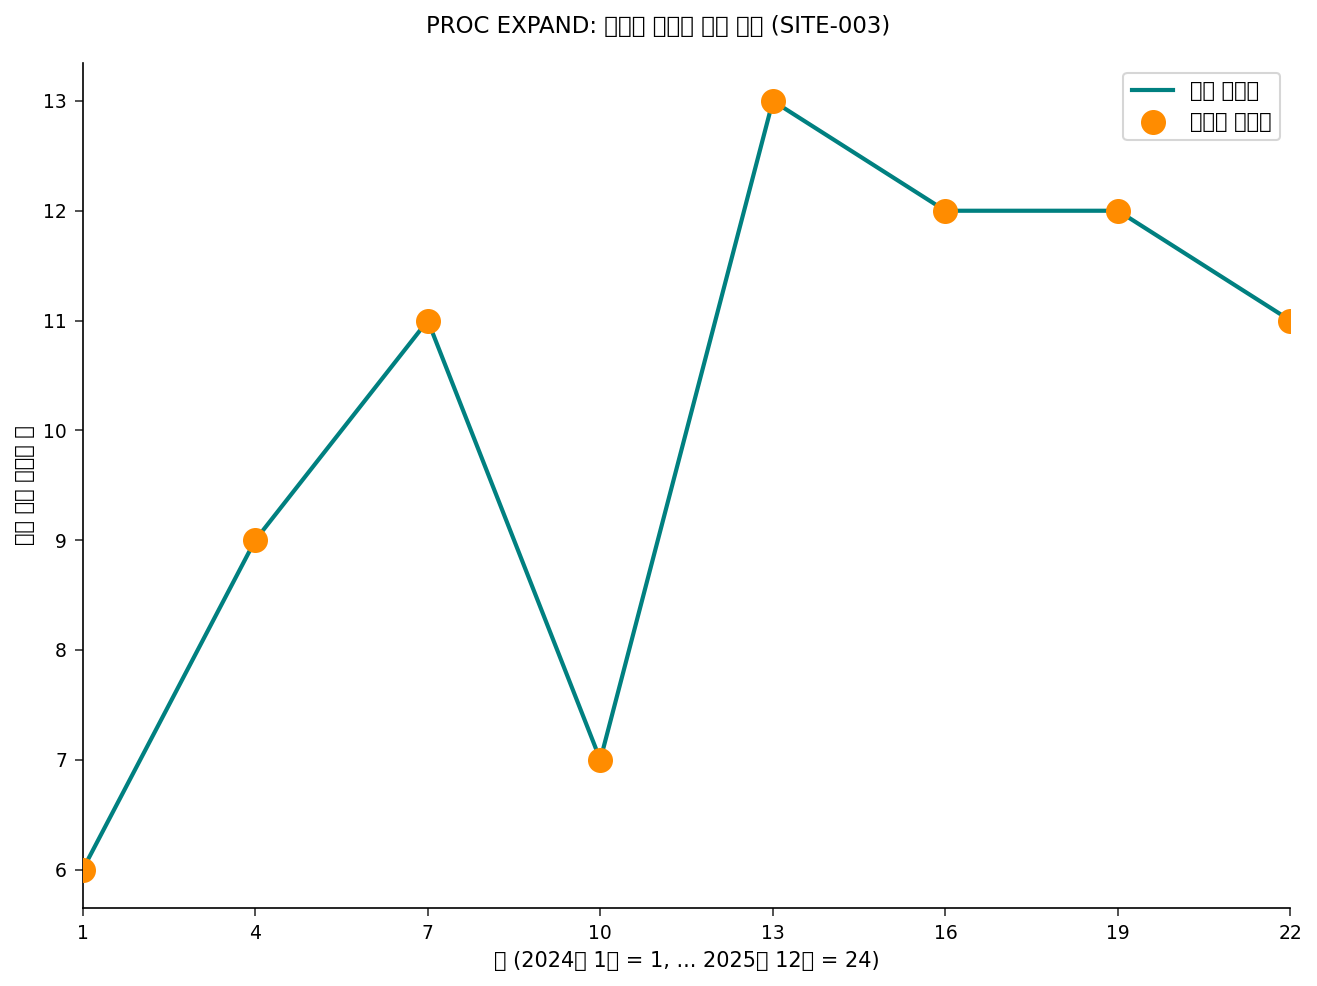

In [7]:
/* --------------------------------------------------------
   ID 변수는 이제 월별 날짜를 담습니다. 다시 형식을 지정하고
   사이트 내 월 인덱스(1..24)를 그래프용으로 추가합니다.
   -------------------------------------------------------- */
데이터 work.enrollment_monthly;
    설정 work.enrollment_monthly;
    기준 site_id;
    형식 month_date monyy7.;
    month_date = quarter_date;
    보존 month_index 0;
    만약 first.site_id 이면 month_index = 0;
    month_index + 1;
    /* 분기 기준월(1, 4, 7, ...)을 표시 */
    만약 mod(month_index - 1, 3) = 0 이면 anchor = enrolled_count;
    아니면 anchor = .;
실행;

/* 한 사이트에 대한 변환 결과 표시: 원래 분기별 기준점을
   통과하는 보간된 월별 선. */
처리 SGPLOT 데이터=work.enrollment_monthly;
    조건 site_id = 'SITE-003';
    SERIES x=month_index y=enrolled_count
        / LINEATTRS=(thickness=2 color=teal)
          legendlabel="월별 추정치";
    SCATTER x=month_index y=anchor
        / MARKERATTRS=(SYMBOL=circlefilled size=11 color=darkorange)
          legendlabel="분기별 기준점";
    XAXIS 라벨="월 (2024년 1월 = 1, ... 2025년 12월 = 24)"
        integer VALUES=(1 까지 24 기준 3);
    YAXIS 라벨="월별 등록 피험자 수";
    제목 "PROC EXPAND: 분기별 등록의 월별 보간 (SITE-003)";
실행;


In [8]:
/* --------------------------------------------------------
   월별 추정치를 사이트 메타데이터와 결합한 뒤, 지역별
   월별 등록 현황을 요약합니다.
   -------------------------------------------------------- */
처리 SQL;
    CREATE TABLE work.enrollment_monthly_region AS
    선택 e.site_id, s.region, e.month_date,
           e.enrolled_count      AS monthly_estimate,
           e.cumulative_enrolled AS cumulative_estimate
    FROM work.enrollment_monthly e
    INNER JOIN work.site_master s
        ON e.site_id = s.site_id
    ORDER 기준 s.region, e.site_id, e.month_date;
QUIT;

처리 평균 데이터=work.enrollment_monthly_region n sum mean;
    분류 region;
    변수 monthly_estimate cumulative_estimate;
    라벨 region = "지역"
          monthly_estimate = "월별 등록 추정치"
          cumulative_estimate = "누적 등록 추정치";
    출력 out=work.region_monthly_summary
        sum(monthly_estimate)=total_monthly_enrolled
        mean(monthly_estimate)=avg_monthly_rate;
실행;

처리 인쇄 데이터=work.region_monthly_summary noobs 라벨;
    라벨 region = "지역"
          total_monthly_enrolled = "총 월별 등록 건수"
          avg_monthly_rate = "평균 월별 등록률";
    제목 "지역별 월별 등록 추정치";
실행;


                                                    분기별 지역 등록 건수 기준선                                                    

                                                    분기별 지역 등록 건수 기준선                                                    

                                                  The MEANS Procedure

                              Analysis Variable : monthly_estimate 월별 등록 추정치

        지역                N Obs            Sum           Mean
        -----------------------------------------------------
        북미                   44    326.0000000      7.4090909
        유럽                   44    336.0000000      7.6363636
        -----------------------------------------------------

                            Analysis Variable : cumulative_estimate 누적 등록 추정치

        지역                N Obs            Sum           Mean
        -----------------------------------------------------
        북미                   48   1312.0000000     27.3333333
        유럽                   48


NOTE: PROC SQL 

NOTE: Table work.enrollment_monthly_region created.
NOTE: PROC SQL statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.region_monthly_summary has 3 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.region_monthly_summary

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


---

### 해석

PROC EXPAND는 각 사이트의 날짜를 따라 빈도 변환을 사용해 **32개 분기별 레코드**(4개 사이트 x 8개 분기)를 **96개 월별 레코드**로 변환했습니다. 보간된 월별 시계열은 원래 분기별 기준값을 정확히 통과하며, SITE-003 그림이 이를 보여 줍니다: 주황색 점은 보고된 여덟 개 분기별 건수이고 청록색 선은 이를 연결하는 분해된 월별 추정치입니다.

월 단위로 보면 두 지역은 근접하게 따라갑니다. 유럽은 사이트-월당 평균 **7.64명**, 북미는 **7.41명**을 등록하며, 보간된 지평에 걸친 지역 월별 합계는 각각 **336명**과 **326명**입니다. `METHOD=JOIN`은 마지막 분기별 기준점 이후로 외삽하지 않으므로, 마지막 부분 분기 월들은 추정치를 갖지 않고 월별 평균에서 제외되는데, 이는 향후 계획을 위한 보수적 선택입니다.

이 월별 투영은 임상 운영이 분기별에서 월별 계획 주기로 옮겨 갈 수 있게 합니다 -- 약품 공급 배송 규모 산정, 모니터링 방문 일정 수립, 데이터 안전 모니터링 위원회(Data Safety Monitoring Board)에 등록 보고 -- 시험이 이미 확정한 분기별 수치를 어느 하나 다시 진술하지 않고도.

---

In [9]:
/* --------------------------------------------------------
   후속 계획 도구를 위해 월별 등록 예측치를 내보냅니다.
   -------------------------------------------------------- */
처리 EXPORT 데이터=work.enrollment_monthly_region
    OUTFILE='monthly_enrollment_projections.csv'
    DBMS=csv REPLACE;
실행;

처리 EXPORT 데이터=work.region_monthly_summary
    OUTFILE='region_monthly_enrollment_summary.csv'
    DBMS=csv REPLACE;
실행;



NOTE: PROC EXPORT data=work.enrollment_monthly_region outfile=monthly_enrollment_projections.csv

NOTE: Exported 96 rows to monthly_enrollment_projections.csv.
NOTE: PROC EXPORT data=work.region_monthly_summary outfile=region_monthly_enrollment_summary.csv

NOTE: Exported 3 rows to region_monthly_enrollment_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 기밀
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
제공: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>